# Name
Please write your name down here:  
Peter Brederlow

In [2]:
# YOUR CODE HERE
#Peter Brederlow

In [3]:
# You can write *LaTex* code like this: $\sigma^2$

In [4]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

# Matplotlib basics
Based on http://www.labri.fr/perso/nrougier/teaching/matplotlib/

We advise you to primarily use `matplotlib`'s `pyplot` interface imported with `import matplotlib.pyplot as plt` for the sake of sharing solutions with each other. `pyplot` has a command-oriented approach, where you use function calls to change the internal state of your plot, which your notebook displays at the end.

During this course, we will from time to time use the `seaborn` module. `seaborn` is built on top of `matplotlib`, but it has a more object-oriented interface, and tighter `pandas` integration. For today's tasks matplotlib is certainly enough, but you are free to play around with `seaborn` in whatever spare time that you have.

## A simple sine/cosine plot
### Create a `numpy` array named `X` with 256 values ranging from -Pi to +Pi 

In [5]:
# YOUR CODE HERE
X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
#print(X)

In [6]:
assert 'X' in locals()

### Create two arrays `C`, `S` with values for the cosine/sine of `X`

In [7]:
# YOUR CODE HERE
C, S = np.cos(X), np.sin(X)

In [8]:
assert 'C' in locals()
assert 'S' in locals()

### Plot both curves in one plot using defaults

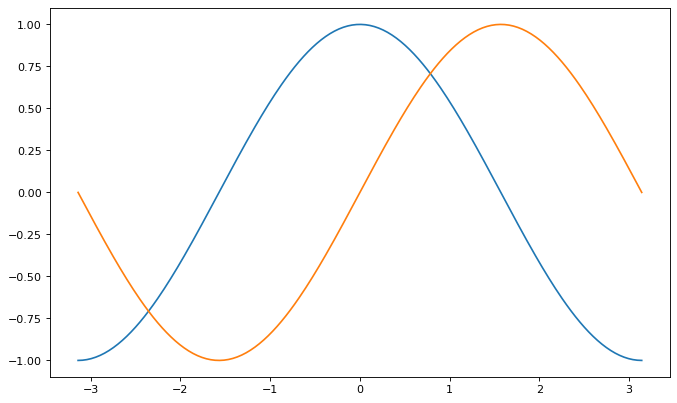

In [9]:
# YOUR CODE HERE
plt.figure(figsize=(10,6), dpi=80)
plt.plot(X, C)
plt.plot(X, S)

### Change the color of the cosine curve to black, and the sine curve to red & Increase the line width of both curves, and the line style of the sine curve to dotted

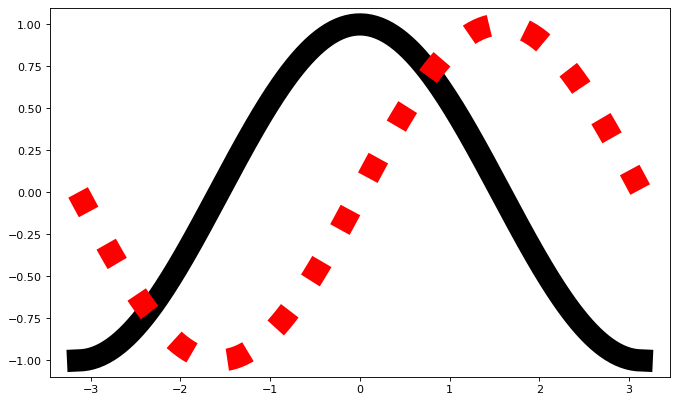

In [10]:
# YOUR CODE HERE
plt.figure(figsize=(10,6), dpi=80)
plt.plot(X, C, color="black", linewidth=20)
plt.plot(X, S, color="red",  linewidth=20, linestyle="dotted")

### Plot the sine and cosine values against each other. If you can recover your high school trigonometry memories: what do you expect to see?

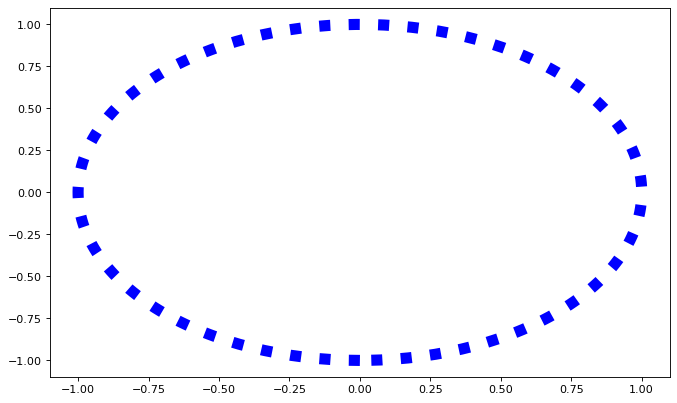

In [11]:
# YOUR CODE HERE
plt.figure(figsize=(10,6), dpi=80)
plt.plot(S, C, color="blue", linewidth=10, linestyle="dotted")

## Exercise: Plot the Normal Distribution
### Try to reproduce the following plot
This is a plot of four different Gaussian distributions from Wikipedia. It was created with a different plotting library, so we aren't aiming to create a perfect 1:1 reproduction. The curves, legend, axis labels, gridlines and at least some kind of major and minor ticks will be enough.

<div class="alert alert-block alert-info"><b>Tip: </b> If you want to avoid implementing a Gaussian probability density function from scratch, you can find one in the package <code>scipy.stats</code>. </div> 


Find out how to put greek letters in labels. Matplotlib supports TeX-like markup.

<img src='https://i.imgur.com/q6HZX2e.png'>

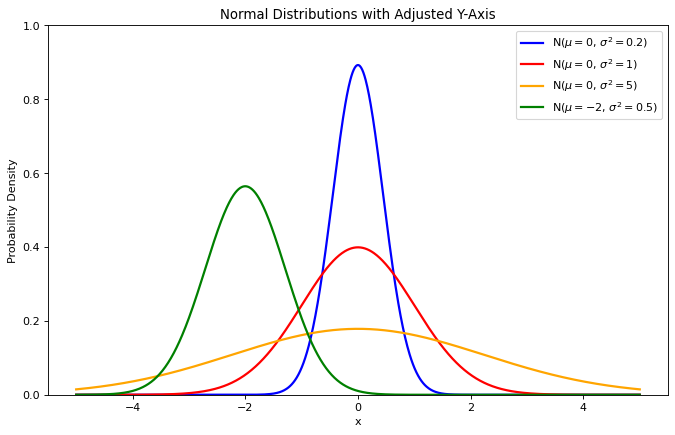

In [12]:
# YOUR CODE HERE
#define distributions
n1 = scipy.stats.norm(loc=0, scale=np.sqrt(0.2))
n2 = scipy.stats.norm(loc=0, scale=np.sqrt(1))
n3 = scipy.stats.norm(loc=0, scale=np.sqrt(5))
n4 = scipy.stats.norm(loc=-2, scale=np.sqrt(0.5))


#plotting
plt.figure(figsize=(10, 6), dpi=80)
x = np.linspace(-5, 5, 1000) 
plt.plot(x, n1.pdf(x), color="blue", linewidth=2, label=r"N($\mu=0$, $\sigma^2=0.2$)")
plt.plot(x, n2.pdf(x), color="red", linewidth=2, label=r"N($\mu=0$, $\sigma^2=1$)")
plt.plot(x, n3.pdf(x), color="orange", linewidth=2, label=r"N($\mu=0$, $\sigma^2=5$)")
plt.plot(x, n4.pdf(x), color="green", linewidth=2, label=r"N($\mu=-2$, $\sigma^2=0.5$)")

# Set y-axis limits to range from 0 to 2
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Normal Distributions with Adjusted Y-Axis")
plt.legend()
plt.show()

### Plot the above distributions as box-plots

In order to turn these probability density functions into values coming from the distributions they represent, you will either have to generate a lot of random numbers for each distribution with `np.random`, or sample them evenly based on their cumulative distribution function. The second approach may require a bit more planning, but it will result in a "cleaner" plot.

Create a `DataFrame` with four columns (one per distribution) and 1000 rows containing the random (or evenly sampled) values, and create a boxplot out of it. 

<div class="alert alert-block alert-info"><b>Tip: </b>  You can either use pandas' integrated plotting capabilities, or use <code>matplotlib</code> or even the package <code>seaborn</code>. </div>

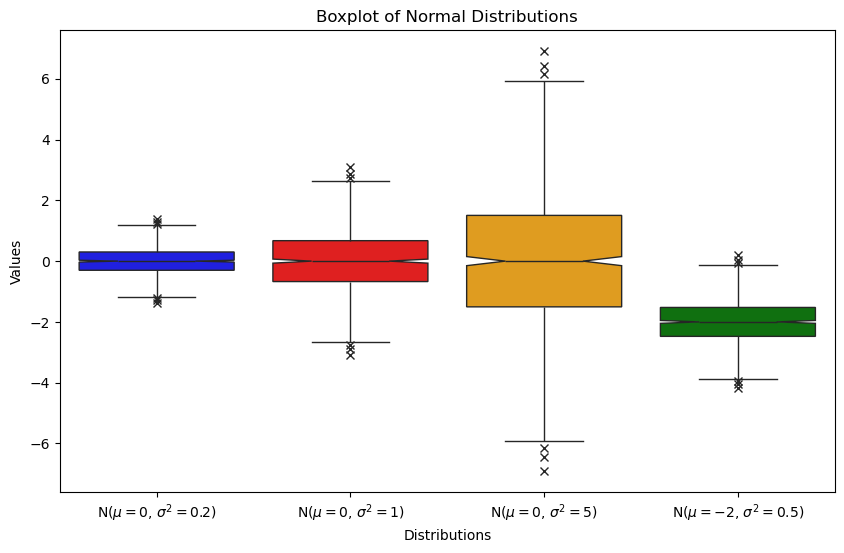

In [13]:
# YOUR CODE HERE
size = 1000
data = { #subsampled 1000 quantiles for each distribution for boxplotting
    r"N($\mu=0$, $\sigma^2=0.2$)": n1.ppf(np.linspace(0.001, 0.999, size)),
    r"N($\mu=0$, $\sigma^2=1$)": n2.ppf(np.linspace(0.001, 0.999, size)),
    r"N($\mu=0$, $\sigma^2=5$)": n3.ppf(np.linspace(0.001, 0.999, size)),
    r"N($\mu=-2$, $\sigma^2=0.5$)": n4.ppf(np.linspace(0.001, 0.999, size)),
}
df = pd.DataFrame(data)

#corresponding colors for distributions for future plottings
colors = { 
    r"N($\mu=0$, $\sigma^2=0.2$)": "blue",
    r"N($\mu=0$, $\sigma^2=1$)": "red",
    r"N($\mu=0$, $\sigma^2=5$)": "orange",
    r"N($\mu=-2$, $\sigma^2=0.5$)": "green",
}

#plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, palette=colors, flierprops={"marker": "x"}, notch = True)
plt.title("Boxplot of Normal Distributions")
plt.ylabel("Values")
plt.xlabel("Distributions")
plt.show()


### ... and as histograms

For this task we strongly suggest the use of `matplotlib`, your job will be easier than with any other package.

To have visual consistency and identical scaling among the histograms, make sure you use identical binning for all four histograms, instead of leaving every setting on default. Set a transparent alpha channel so that the different histograms don't fully occlude each other.

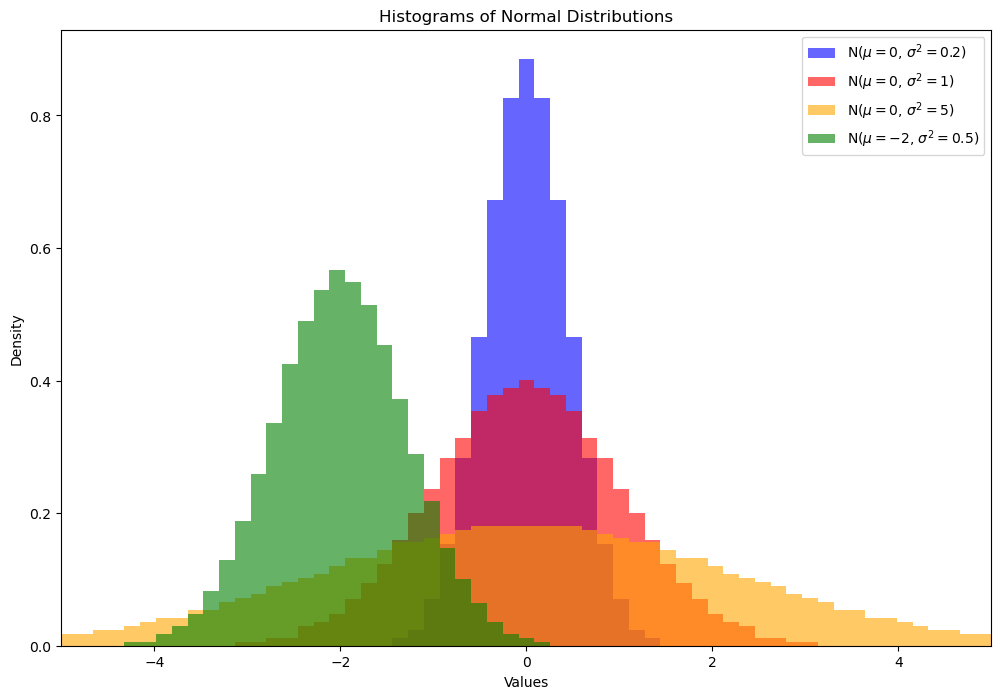

In [14]:
# YOUR CODE HERE
#define bins for next tasks
bins = np.linspace(-5,5,60)

#plot histogram
plt.figure(figsize=(12, 8))
for column in df.columns:
    plt.hist(df[column], bins=bins, alpha=0.6, label=column, density=True, color=colors[column])
plt.xlim(-5, 5)
plt.title("Histograms of Normal Distributions")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.show()

### Bonus task: Plot the distributions as a heatmap

If we had had more than just four distributions to plot, the histogram would quickly become too crowded and hard to read. A potential alternative to a set of histograms would be a heatmap, where each row would contain the binned values of the previous histograms.

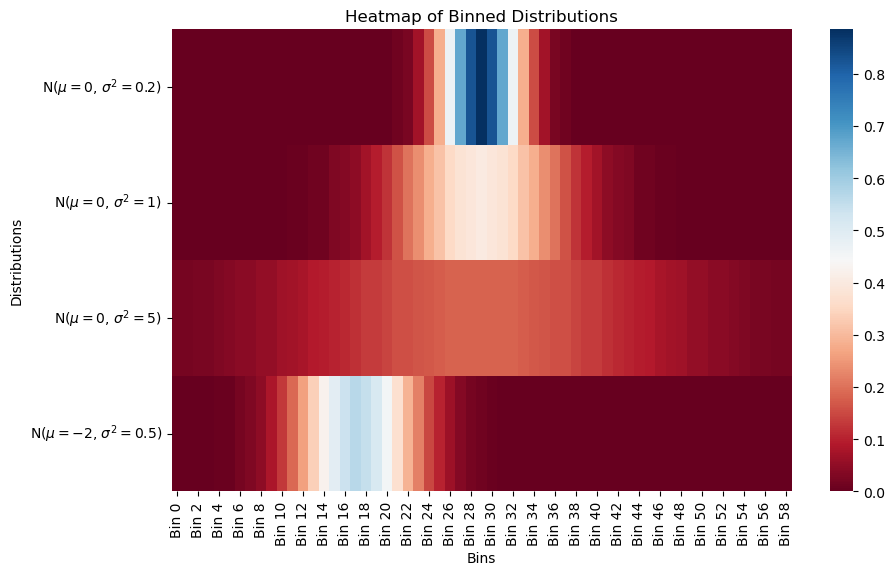

In [15]:
# YOUR CODE HERE
binned_data = {name: np.histogram(values, bins=bins, density=True)[0] for name, values in data.items()}
heatmap_df = pd.DataFrame(binned_data, index=[f"Bin {i}" for i in range(len(bins) - 1)])

#plotting
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df.T, cmap="RdBu", cbar=True, annot=False)
plt.title("Heatmap of Binned Distributions")
plt.xlabel("Bins")
plt.ylabel("Distributions")
plt.show()